<a href="https://colab.research.google.com/github/shivamguptamsi/PyTorch-Deeplearning/blob/main/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn # nn neural network building block
import numpy as np
import matplotlib.pyplot as plt


torch.__version__

'2.11.0+cpu'

In [47]:

def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")

  # Plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14});

#BUILDING A MODEL

* **`nn.Module`** contains the larger building blocks (layers)
* **`nn.Parameter`** contains the smaller parameters like weights and biases (put these together to make nn.Module(s))
* **`forward()`** tells the larger blocks how to make calculations on inputs (tensors full of data) within nn.Module(s)
* **`torch.optim`** contains optimization methods on how to improve the parameters within nn.Parameter to better represent input data

In [71]:
class LinearRegressionModel(nn.Module): # <--- this is subclass , this give access/ inherid all functionality from nn.Module
  def __init__(self) -> None: # <--- This is the constructor. It's the method that runs automatically whenever you create a new instance of the class.
    super().__init__()# <---- gives you access to the parent class (nn.Module)
    self.weights = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32)) # <--- used with Module s - when they’re assigned as Module attributes they are automatically added to the list of its parameters.

    self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))

  def forward(self, x:torch.Tensor) -> torch.Tensor: # x is the input data, "->" means this function is expected to return a torch.Tensor.
      return self.weights * x + self.bias # linear regression


In [72]:
model_1 = LinearRegressionModel()
model_1.state_dict()

OrderedDict([('weights', tensor([0.2714])), ('bias', tensor([-0.0738]))])

In [73]:
list(model_1.parameters())

[Parameter containing:
 tensor([0.2714], requires_grad=True),
 Parameter containing:
 tensor([-0.0738], requires_grad=True)]

In [74]:
type(nn.parameter), type(nn.Parameter)

(module, torch.nn.parameter._ParameterMeta)

In [75]:

weight = 0.7
bias = 0.3


start = 0
end = 1
step = 0.143
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]


(tensor([[0.0000],
         [0.1430],
         [0.2860],
         [0.4290],
         [0.5720],
         [0.7150],
         [0.8580]]),
 tensor([[0.3000],
         [0.4001],
         [0.5002],
         [0.6003],
         [0.7004],
         [0.8005],
         [0.9006]]))

#TRAINING

Right now our model is making predictions using random parameters to make calculations, it's basically guessing (randomly).
To fix that, we can update its internal parameters (I also refer to parameters as patterns), the weights and bias values we set randomly using nn.Parameter() and torch.randn() to be something that better represents the data.

In [76]:
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(5, 5, 2, 2)

In [77]:
with torch.inference_mode():
  y_predictions = model_1(X_test)

In [78]:
y_predictions

tensor([[0.1202],
        [0.1591]])

In [79]:
y_test

tensor([[0.8005],
        [0.9006]])

In [80]:
loss_fn = nn.L1Loss() #takes x, y where x is the predicted value and y is the targetted value

In [81]:
#learn about NN

##Backpropagation and Gradient descent



In [82]:
optimizer = torch.optim.SGD(params = model_1.parameters(), #assign the parameter of the model for optimizing
                            lr = 0.01 #how much the optimizer change the parameter in each step
                            )

##Building a training loop
1. Loop through the data
2. Forword pass (this involves moving data through the model's forward funtion `forward()`) to make prediction on data - also called forward propagation.
3. Calculating the loss by comparing the predicted value with target value.
4. Optimising it

##__Loss Function__ (L1loss)
###Parameters:-
-> `size_average(bool, optional)` By default losses are averaged over each loss element in the batch and when set to `false`, the losses are instead summed for each minibatch. Ignored when `reduce` is `false`.

->`reduce(bool, optional)` When reduce is `false`, returns a loss per batch element instead and ignores `size_average`. Default: `True`

->`reduction(str, optional)` `mean`: the sum of the output will be divided by the number of elements in the output, `sum`: the output will be summed. __size_average__ and __reduce__ are in the process of being deprecated, and in the meantime, specifying either of those two args will override `reduction`. Default `mean`.


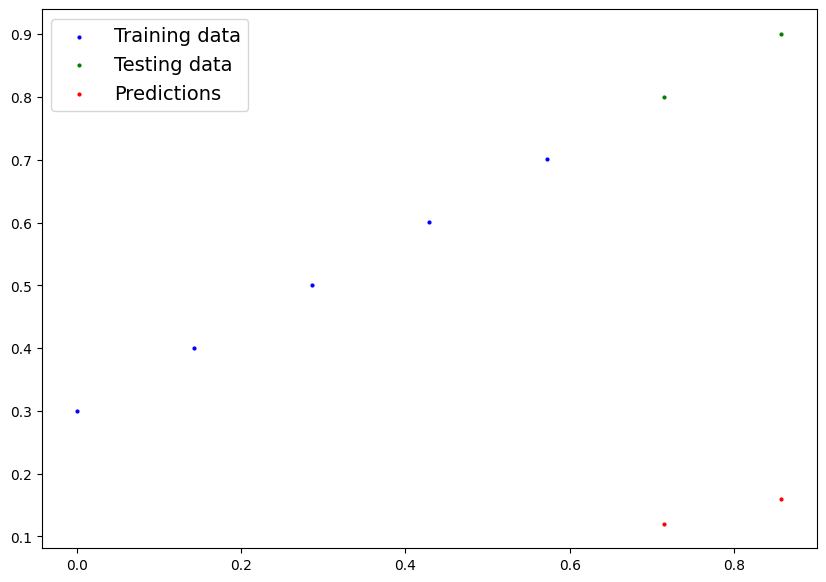

In [83]:
plot_predictions(X_train, y_train, X_test, y_test, y_predictions)

In [84]:

#Training LOOP
# An epoch is one loop through the data././././
epocha  = 1000
for epoch in range(epocha):
  model_1.train() # train mode in Pytorch set all parameters that required graidents to requires gradients

  #step 1
  y_pred = model_1(X_train)

  #calculating the loss
  loss = loss_fn(y_pred, y_train)

  #optimizing zero grad
  optimizer.zero_grad()

  #-------
  loss.backward()

  optimizer.step()

  model_1.eval()

model_1.state_dict()

OrderedDict([('weights', tensor([0.6901])), ('bias', tensor([0.2942]))])

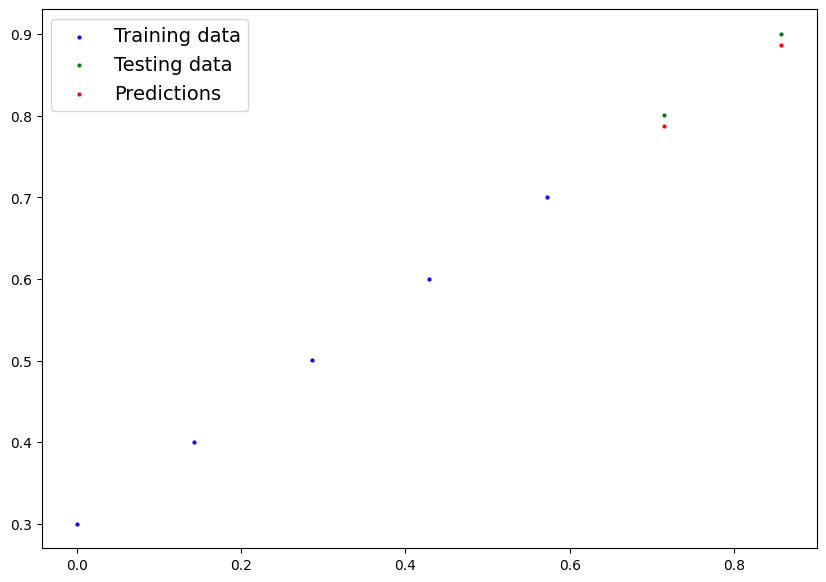

In [85]:
with torch.inference_mode():
  y_preds = model_1(X_test)
plot_predictions(predictions=y_preds)